# Calculate EOS with QEpy

### To run this tutorial in google colab click the following link :

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/asesma-org/miniASESMA2026/blob/main/Week1/Day3/hands-on-eos/hands-on_eos.ipynb)

In [ ]:
## Uncomment the following lines for Colab. IMPORTANT NOTE: install first qepy and then dftpy
# !pip install qepy f90wrap==0.2.16

In [ ]:
# !python -m pip install "git+https://github.com/Quantum-MultiScale/DFTpy.git@dev"

In [1]:
import numpy as np
from ase.build import bulk
from ase.io.trajectory import Trajectory
#
from qepy.calculator import QEpyCalculator

In [2]:
qe_options = {
    '&control': {
        'calculation': "'vc-relax'",
        'pseudo_dir': "'./'",
    },
    '&system': {
        'degauss': 0.005,
        'ecutwfc': 30,
        'occupations': "'smearing'"
    },
    'atomic_species': ['Al  26.98 Al.pbe-nl-kjpaw_psl.1.0.0.UPF'],
    'k_points automatic': ['10 10 10 1 1 1'],
}

In [3]:
!wget http://pseudopotentials.quantum-espresso.org/upf_files/Al.pbe-nl-kjpaw_psl.1.0.0.UPF

URL transformed to HTTPS due to an HSTS policy
--2026-06-13 23:47:18--  https://pseudopotentials.quantum-espresso.org/upf_files/Al.pbe-nl-kjpaw_psl.1.0.0.UPF
Resolving pseudopotentials.quantum-espresso.org (pseudopotentials.quantum-espresso.org)... 93.186.242.122
Connecting to pseudopotentials.quantum-espresso.org (pseudopotentials.quantum-espresso.org)|93.186.242.122|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 964489 (942K)
Saving to: ‘Al.pbe-nl-kjpaw_psl.1.0.0.UPF.1’

Al.pbe-nl-kjpaw_psl 100%[===================>] 941.88K   249KB/s    in 3.8s    

2026-06-13 23:47:27 (249 KB/s) - ‘Al.pbe-nl-kjpaw_psl.1.0.0.UPF.1’ saved [964489/964489]



In [4]:
al = bulk('Al', 'fcc', a=4.05)

In [5]:
al.calc=QEpyCalculator(qe_options=qe_options, logfile=True)

In [6]:
%%time
traj = Trajectory('tmp.traj', 'w')
cell = al.get_cell()
volumes = []
energies = []
for x in np.linspace(0.9, 1.1, 6):
    al.set_cell(cell * x, scale_atoms=True)
    vol = al.get_volume()
    ene = al.get_potential_energy()
    volumes.append(vol)
    energies.append(ene)
    traj.write(al)

CPU times: user 22 s, sys: 5.09 s, total: 27.1 s
Wall time: 19.5 s


77.19469021073594 GPa


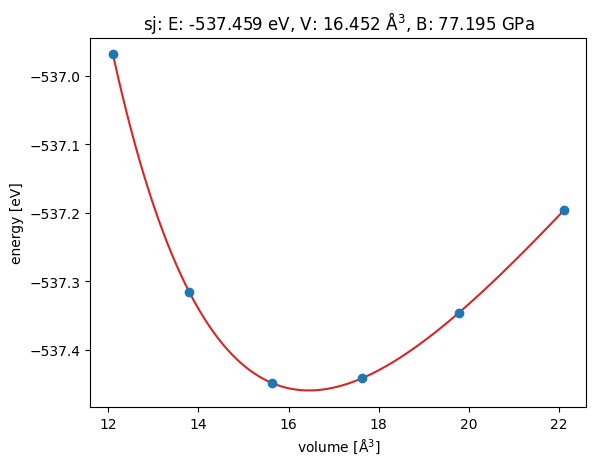

In [7]:
from ase.units import kJ
from ase.eos import EquationOfState
eos = EquationOfState(volumes, energies)
v0, e0, B = eos.fit()
print(B / kJ * 1.0e24, 'GPa')
eos.plot('tmp.eos.png');